In [32]:
import pandas as pd

data = pd.read_csv("spotify_songs.csv")

In [33]:
# eliminació de les columnes amb IDs
data.drop(columns={
    "track_id",
    "track_album_id",
    "playlist_id"
}, inplace=True)

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_name                32828 non-null  object 
 1   track_artist              32828 non-null  object 
 2   track_popularity          32833 non-null  int64  
 3   track_album_name          32828 non-null  object 
 4   track_album_release_date  32833 non-null  object 
 5   playlist_name             32833 non-null  object 
 6   playlist_genre            32833 non-null  object 
 7   playlist_subgenre         32833 non-null  object 
 8   danceability              32833 non-null  float64
 9   energy                    32833 non-null  float64
 10  key                       32833 non-null  int64  
 11  loudness                  32833 non-null  float64
 12  mode                      32833 non-null  int64  
 13  speechiness               32833 non-null  float64
 14  acoust

In [35]:
# Eliminació dels pocs valors perduts que hi han
data.dropna(axis="index", inplace=True)

In [36]:
data["playlist_name"] = [str.strip(name) for name in data["playlist_name"]]

playlist_counts = pd.DataFrame(data.groupby(by="playlist_name").count()["track_name"])
playlist_counts.rename(columns={"track_name": "playlist_size"}, inplace=True)

# Fusiona i ordena per nombre de temes a la playlist
data = data.merge(playlist_counts, on="playlist_name", how="inner", validate="many_to_one")
data.sort_values(by="playlist_size", inplace=True)

In [37]:
# Eliminació de temes duplicats. Es manté per a cada tema repetit la còpia que pertany a la playlist amb menys cançons
data.drop_duplicates(subset="track_name", keep="last", inplace=True, ignore_index=True)

In [38]:
# Distribució de les variable objectiu: playlist_genre i playlist_subgenre
print(data["playlist_genre"].value_counts())

playlist_genre
rap      4590
edm      4315
r&b      3846
pop      3647
latin    3619
rock     3432
Name: count, dtype: int64


In [39]:
for genre in set(data["playlist_genre"]):
    print("\n", genre)
    print(data.query("playlist_genre == @genre")["playlist_subgenre"].value_counts())


 edm
playlist_subgenre
progressive electro house    1388
electro house                1145
pop edm                       962
big room                      820
Name: count, dtype: int64

 rap
playlist_subgenre
southern hip hop    1359
gangster rap        1119
hip hop             1078
trap                1034
Name: count, dtype: int64

 r&b
playlist_subgenre
neo soul              1298
urban contemporary    1094
hip pop                757
new jack swing         697
Name: count, dtype: int64

 latin
playlist_subgenre
latin hip hop    1181
tropical          983
latin pop         932
reggaeton         523
Name: count, dtype: int64

 pop
playlist_subgenre
indie poptimism    1291
electropop          878
dance pop           774
post-teen pop       704
Name: count, dtype: int64

 rock
playlist_subgenre
hard rock         1028
permanent wave     861
album rock         812
classic rock       731
Name: count, dtype: int64


In [40]:
# Dades per visualització de freqüències de gèneres i subgèneres
plot_data = data[["track_name", "playlist_genre", "playlist_subgenre"]]
plot_data = plot_data.groupby(by=["playlist_genre", "playlist_subgenre"], as_index=False).count()
plot_data.rename(columns={"playlist_genre": "Genre", "playlist_subgenre": "Subgenre", "track_name": "Count"}, inplace=True)

plot_data = pd.pivot(plot_data, columns="Subgenre", index="Genre", values="Count").fillna(0)
plot_data.to_csv("plot_data/genre_subgenre_freqs.csv")

In [41]:
# Transformació de track_album_release_date en anys
album_release_date = [str.split(date, sep="-")[0] for date in data["track_album_release_date"]]

# Comprovació
import re

pattern = r"^[1-2][0-9]{3}$"
print("Nou format correcte: {}".format(
    all(re.fullmatch(pattern, date) for date in album_release_date))
)

# Anys a dècades
album_release_date = [re.sub(pattern=r"[0-9]$", repl="0s", string=date) for date in album_release_date]
data["track_album_release_date"] = album_release_date


Nou format correcte: True


In [42]:
# Dades per visualització de gènere musical segons la data de llançament del disc
plot_data = data[["track_name", "playlist_genre", "track_album_release_date"]]
plot_data = plot_data.groupby(by=["playlist_genre", "track_album_release_date"], as_index=False).count()

plot_data.rename(columns={"playlist_genre": "Genre", "track_album_release_date": "Year", "track_name": "Count"}, inplace=True)
plot_data = plot_data.query("Year != '2020s'")

plot_data = pd.pivot(plot_data, columns="Genre", index="Year", values="Count").fillna(0)
plot_data.to_csv("plot_data/genre_by_release_date.csv")

In [43]:
# Popularitat a spotify

# Conversió a factor ordinal entre 0 i 4
data["Popularity"] = [4 if value == 100 else value//20 for value in data["track_popularity"]]

In [44]:
# Dades per visualització de popularitat

plot_data = data[["track_name", "playlist_genre", "Popularity"]]
plot_data = plot_data.groupby(by=["playlist_genre", "Popularity"], as_index=False).count()

plot_data.rename(columns={"playlist_genre": "Genre", "track_name": "Count"}, inplace=True)

plot_data = pd.pivot(plot_data, columns="Genre", index="Popularity", values="Count").fillna(0)
plot_data.to_csv("plot_data/genre_by_popularity.csv")

In [45]:
# Key i mode
data["mode"] = ["minor" if value == 0 else "major" for value in data["mode"]]

key_mapping = {
    0: "C",
    1: "C#",
    2: "D",
    3: "D#",
    4: "E",
    5: "F",
    6: "F#",
    7: "G",
    8: "G#",
    9: "A",
    10: "A#",
    11: "B"
}

data["key"] = [key_mapping[key] for key in data["key"]]

In [46]:
# Dades visualització de tons i modes

plot_data = data[["track_name", "playlist_genre"]]
plot_data["key_mode"] = [key + " " + mode for key, mode in zip(data["key"], data["mode"])]
plot_data = plot_data.groupby(by=["playlist_genre", "key_mode"], as_index=False).count()
plot_data.rename(columns={"playlist_genre": "Genre", "key_mode": "Key", "track_name": "Count"}, inplace=True)
plot_data["Percentage"] = 100*plot_data["Count"] / plot_data.groupby("Genre")["Count"].transform('sum')

plot_data = pd.pivot(plot_data, columns="Key", index="Genre", values="Percentage").fillna(0)
plot_data.to_csv("plot_data/genre_by_key_mode.csv")

/tmp/ipykernel_3699/477134229.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["key_mode"] = [key + " " + mode for key, mode in zip(data["key"], data["mode"])]


In [47]:
# Variables numèriques d'interès
data["duration_ms"] = [duration//1000 for duration in data["duration_ms"]]
data.rename(columns={"duration_ms": "duration"}, inplace=True)

num_vars = [
    "danceability",
    "energy",
    "loudness",
    "valence",
    "tempo",
    "duration"
]

In [48]:
# Correlacions
num_data = data[num_vars]
corr = num_data.corr()
corr

,danceability,energy,loudness,valence,tempo,duration
danceability,1.000000,-0.072663,0.018534,0.332336,-0.173550,-0.085175
energy,-0.072663,1.000000,0.684437,0.155131,0.152141,0.029287
loudness,0.018534,0.684437,1.000000,0.055975,0.098510,-0.090022
valence,0.332336,0.155131,0.055975,1.000000,-0.020457,-0.047739
tempo,-0.173550,0.152141,0.098510,-0.020457,1.000000,0.003517
duration,-0.085175,0.029287,-0.090022,-0.047739,0.003517,1.000000


In [49]:
# Dades per a la visualització de correlacions

X = [num_vars[i//6] for i in range(36)]
Y = num_vars*6
values = [corr.loc[x, y] for x, y in zip(X, Y)]

plot_data = pd.DataFrame(
    {
        "X": X,
        "Y": Y,
        "correlation": values
    }
)

plot_data.to_csv("plot_data/correlations.csv")

In [50]:
# Visualització dels resums estadístics segons el gènere musical
summary_list = []

for genre in set(data["playlist_genre"]):
    x = data.query("playlist_genre == @genre")
    x = x[num_vars].describe().T.reset_index()
    x["Genre"] = [genre for i in range(len(x))]
    x.rename(columns={"index": "var"}, inplace=True)
    summary_list.append(x)

plot_data = pd.concat(summary_list).reset_index(drop=True)
plot_data.drop(columns="count", inplace=True)

# Escalar les variables
from statistics import mean, stdev

stats = ["mean", "std", "min", "25%", "50%", "75%", "max"]

for var in plot_data["var"]:
    var_data = plot_data.query("var == @var")
    for stat in stats:
        m = mean(var_data[stat])
        sd = stdev(var_data[stat])

        scale = lambda x: ((x - m)/sd) + 5
        plot_data.loc[plot_data["var"] == var, [stat]] = [scale(x) for x in var_data[stat]]


plot_data.to_csv("plot_data/numerical_summary.csv")

In [51]:
# Distribucions de cada variable numèrica
def generate_dist_plot_data(var: str) -> pd.DataFrame:
    genre_data_list = []
    for genre in set(data["playlist_genre"]):
        genre_data_list.append(data.query("playlist_genre == @genre")[[var, "playlist_genre"]])
    return pd.concat(genre_data_list)

for var in num_vars:
    generate_dist_plot_data(var).to_csv("plot_data/" + var + "_distribution.csv")

In [52]:
# Es pot predir el gènere d'un tema a partir d'altres atributs?

# Creació de dummies
predictors = [*num_vars, "mode", "Popularity"]
predictors.remove("loudness")
X = data[predictors]
y = data["playlist_genre"]

X = pd.get_dummies(X, dtype=int)

In [53]:
# Train-test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Accuracy: 0.45245202558635395
F1-Score: 0.4248565088689624
ROC-AUC: 0.6653282120274785


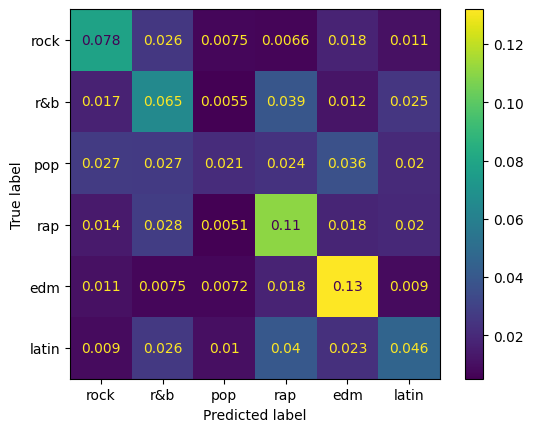

In [54]:
# Funció d'avaluació
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def dummify_y(y, classes):
    dummified = []
    for c in classes:
        dummified.append([1 if v == c else 0 for v in y])
    return np.transpose(dummified)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    classes = ["rock", "r&b", "pop", "rap", "edm", "latin"]
    y_test_dummy = dummify_y(y_test, classes)
    y_pred_dummy = dummify_y(y_pred, classes)

    print("Accuracy: {}".format(accuracy_score(y_test, y_pred)))
    print("F1-Score: {}".format(f1_score(y_test, y_pred, average="macro",
                                              labels=classes)))
    print("ROC-AUC: {}".format(roc_auc_score(y_test_dummy, y_pred_dummy, multi_class="ovr",
                                              labels=classes)))
    conf_m = confusion_matrix(y_test, y_pred, labels=classes, normalize="all")
    display = ConfusionMatrixDisplay(conf_m, display_labels=classes)
    display.plot()
    plt.show()
    return conf_m

# Enfocament One vs Rest amb random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

rf = OneVsRestClassifier(RandomForestClassifier(max_depth=4, max_leaf_nodes=24, random_state=42))

rf.fit(X_train, y_train)
conf_m_multiclass = evaluate_model(rf, X_test, y_test)


In [55]:
# Visualització de la matriu de confusió
classes = ["rock", "r&b", "pop", "rap", "edm", "latin"]
plot_data = pd.DataFrame(conf_m_multiclass, index=classes, columns=classes)

plot_data.to_csv("plot_data/multiclass_conf_matrix.csv")

Accuracy: 0.8407249466950959
F1-Score: 0.61907190209077
ROC-AUC: 0.787530721067393
Sensitivity: 0.7033603707995365
Specificity: 0.8717010713352495
Prevalence: 0.1840085287846482


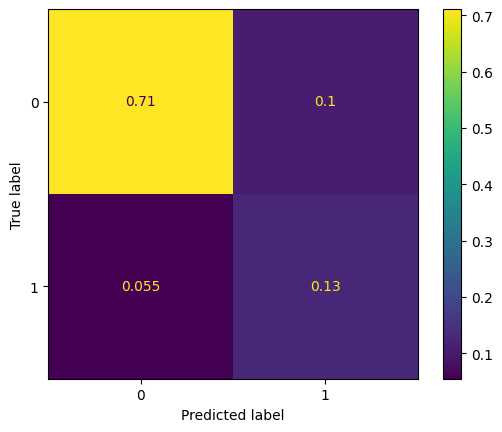

In [56]:
# Classificador binari
def evaluate_bin_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Accuracy: {}".format(accuracy_score(y_test, y_pred)))
    print("F1-Score: {}".format(f1_score(y_test, y_pred)))
    print("ROC-AUC: {}".format(roc_auc_score(y_test, y_pred)))
    conf_m = confusion_matrix(y_test, y_pred, normalize="all")
    print("Sensitivity: {}".format(conf_m[1,1]/(conf_m[1,0]+conf_m[1,1])))
    print("Specificity: {}".format(conf_m[0,0]/(conf_m[0,0]+conf_m[0,1])))
    print("Prevalence: {}".format((conf_m[1,0]+conf_m[1,1])/(conf_m[0,0]+conf_m[0,1]+conf_m[1,0]+conf_m[1,1])))
    display = ConfusionMatrixDisplay(conf_m)
    display.plot()
    plt.show()
    return conf_m

# Gènere "edm", el més senzill de classificar
genre = "edm"
y_train_bin = [1 if value == genre else 0 for value in y_train]
y_test_bin = [1 if value == genre else 0 for value in y_test]

from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier

smote = SMOTE(sampling_strategy=1, random_state=42)
X_train_res, y_train_bin_res = smote.fit_resample(X_train, y_train_bin)

model = DecisionTreeClassifier(max_depth=4, max_leaf_nodes=8, random_state=42)
model.fit(X_train_res, y_train_bin_res)
conf_m = evaluate_bin_model(model, X_test, y_test_bin)

In [57]:
# Visualització de la matriu de confusió per edm
plot_data = pd.DataFrame(conf_m, index=["altre", "edm"], columns=["altre", "edm"])

plot_data.to_csv("plot_data/edm_conf_matrix.csv")

In [58]:
# Feature importance dels atributs
plot_data = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

plot_data = plot_data.query("importance > 0").sort_values(by="importance", ascending=False)

plot_data.to_csv("plot_data/feature_importance.csv")

In [59]:
# Extracció de les regles de decisió
from sklearn import tree
import graphviz

decision_rules = tree.export_graphviz(model, feature_names=X.columns, class_names=["0", "1"],
                                      impurity=False, filled=True, special_characters=True, proportion=True)

graph = graphviz.Source(decision_rules)
graph.format = "png"
graph.render("decision_tree_rules.png", directory="plot_data")

'plot_data/decision_tree_rules.png.png'